# Augmentation Exploration
Visually test rotation boundaries, zoom range, and brightness/contrast settings on real palm vein images before locking values into `dataset.py`.

Subjects: 60
Size: (224, 224), Mode: L


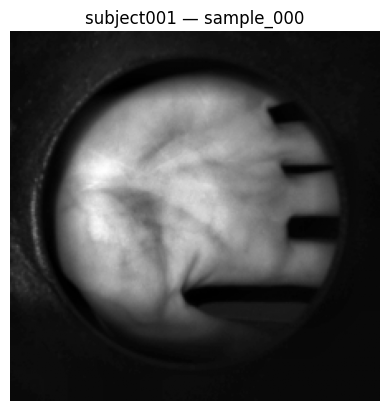

In [1]:
import os
from PIL import Image
import matplotlib.pyplot as plt

DATASET = r'c:\Users\riyat\OneDrive\Documents\palmvein\data\processed'

subjects = sorted(os.listdir(DATASET))
print(f'Subjects: {len(subjects)}')

# Load one sample image to work with
img = Image.open(os.path.join(DATASET, subjects[0], 'sample_000.png'))
print(f'Size: {img.size}, Mode: {img.mode}')

plt.imshow(img, cmap='gray')
plt.title(f'{subjects[0]} — sample_000')
plt.axis('off')
plt.show()


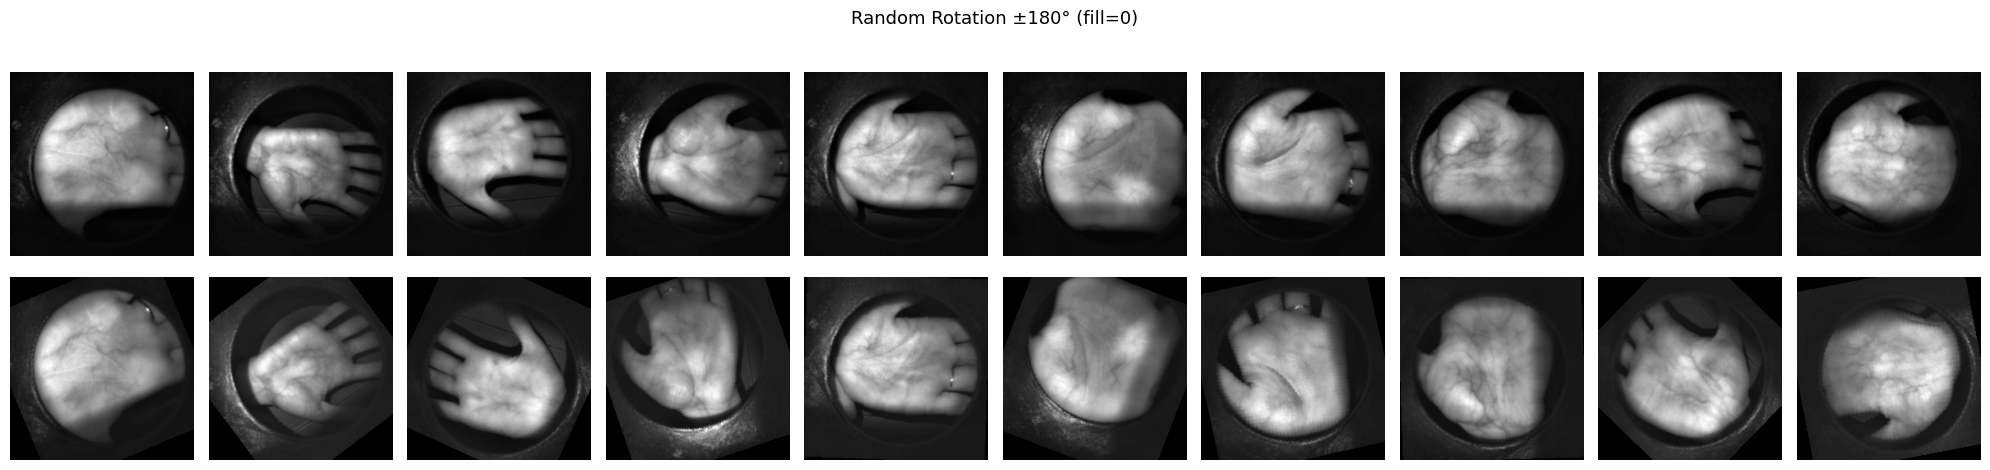

In [2]:
import random
import numpy as np
from torchvision import transforms as T

# Pick 10 random images from across subjects
random.seed(None)  # fresh randomness each run
sample_paths = []
for subj in random.sample(subjects, 10):
    fname = random.choice(os.listdir(os.path.join(DATASET, subj)))
    sample_paths.append(os.path.join(DATASET, subj, fname))

rotate = T.RandomRotation(degrees=180, fill=0)

fig, axes = plt.subplots(2, 10, figsize=(20, 5))
for i, path in enumerate(sample_paths):
    img = Image.open(path)
    rotated = rotate(img)
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(rotated, cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=10)
axes[1, 0].set_ylabel('Rotated', fontsize=10)
plt.suptitle('Random Rotation ±180° (fill=0)', fontsize=13)
plt.tight_layout()
plt.show()


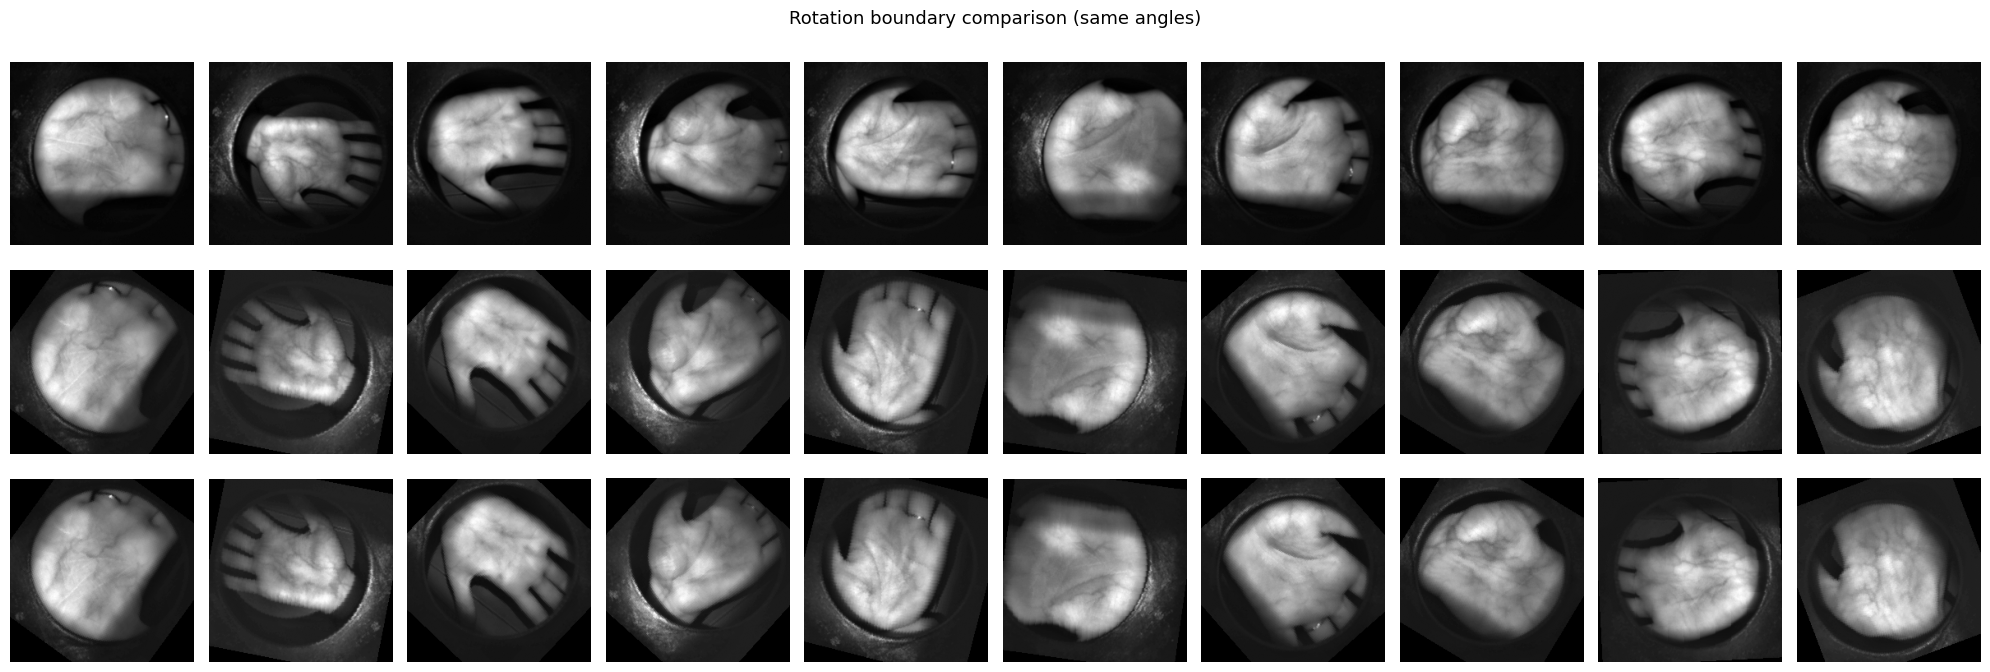

In [3]:
from torchvision.transforms import functional as TF

def rotate_with_pad(img, angle, pad=60):
    """Pad → rotate → center crop back to original size."""
    w, h = img.size
    img_padded = T.Pad(pad, fill=0)(img)
    img_rotated = TF.rotate(img_padded, angle, fill=0)
    # crop back to original size from center
    img_cropped = TF.center_crop(img_rotated, (h, w))
    return img_cropped

angles = [random.uniform(-180, 180) for _ in range(10)]

fig, axes = plt.subplots(3, 10, figsize=(20, 7))
for i, path in enumerate(sample_paths):
    img = Image.open(path)
    angle = angles[i]
    rotated_black = TF.rotate(img, angle, fill=0)
    rotated_pad   = rotate_with_pad(img, angle, pad=60)

    axes[0, i].imshow(img, cmap='gray');           axes[0, i].axis('off')
    axes[1, i].imshow(rotated_black, cmap='gray'); axes[1, i].axis('off')
    axes[2, i].imshow(rotated_pad, cmap='gray');   axes[2, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=9)
axes[1, 0].set_ylabel('fill=0', fontsize=9)
axes[2, 0].set_ylabel('pad+crop', fontsize=9)
plt.suptitle('Rotation boundary comparison (same angles)', fontsize=13)
plt.tight_layout()
plt.show()


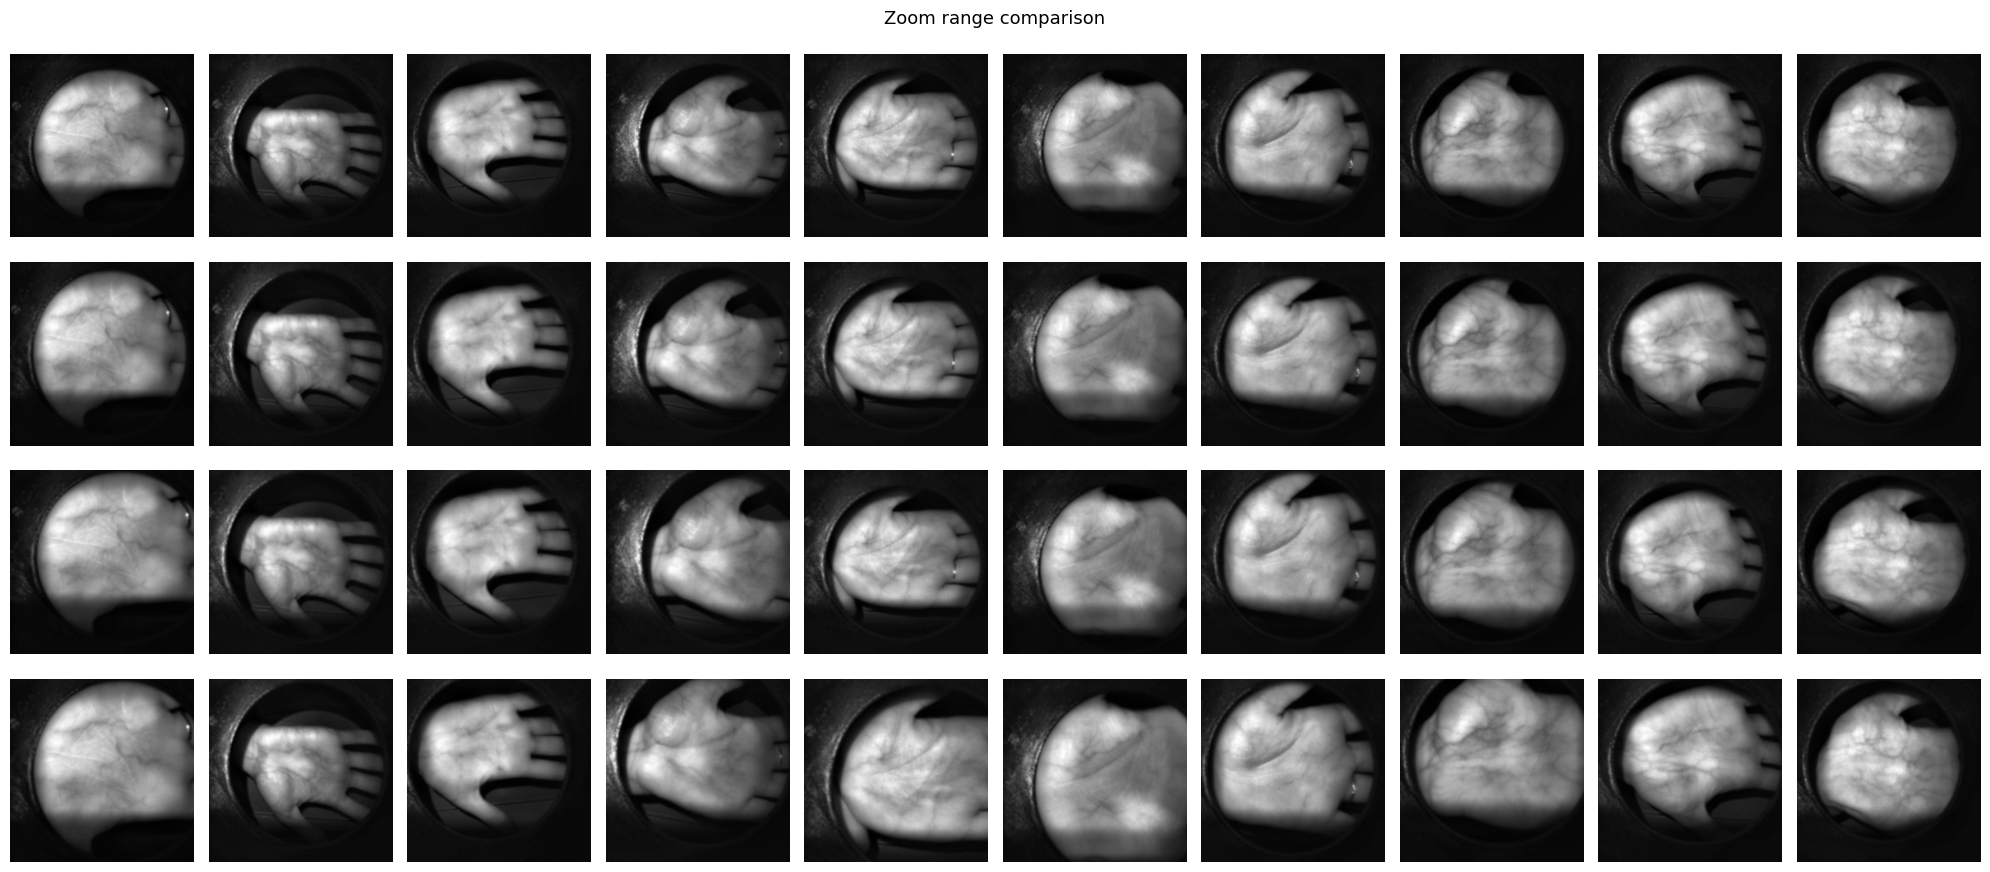

In [4]:
from torchvision import transforms as T

zoom_ranges = [(0.9, 1.0), (0.75, 1.0), (0.6, 1.0)]
labels      = ['mild (0.9–1.0)', 'moderate (0.75–1.0)', 'aggressive (0.6–1.0)']

fig, axes = plt.subplots(len(zoom_ranges) + 1, 10, figsize=(20, 9))

for i, path in enumerate(sample_paths):
    axes[0, i].imshow(Image.open(path), cmap='gray')
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=9)

for r, (scale, label) in enumerate(zip(zoom_ranges, labels)):
    zoom = T.RandomResizedCrop(size=224, scale=scale, ratio=(0.95, 1.05))
    for i, path in enumerate(sample_paths):
        axes[r + 1, i].imshow(zoom(Image.open(path)), cmap='gray')
        axes[r + 1, i].axis('off')
    axes[r + 1, 0].set_ylabel(label, fontsize=9)

plt.suptitle('Zoom range comparison', fontsize=13)
plt.tight_layout()
plt.show()


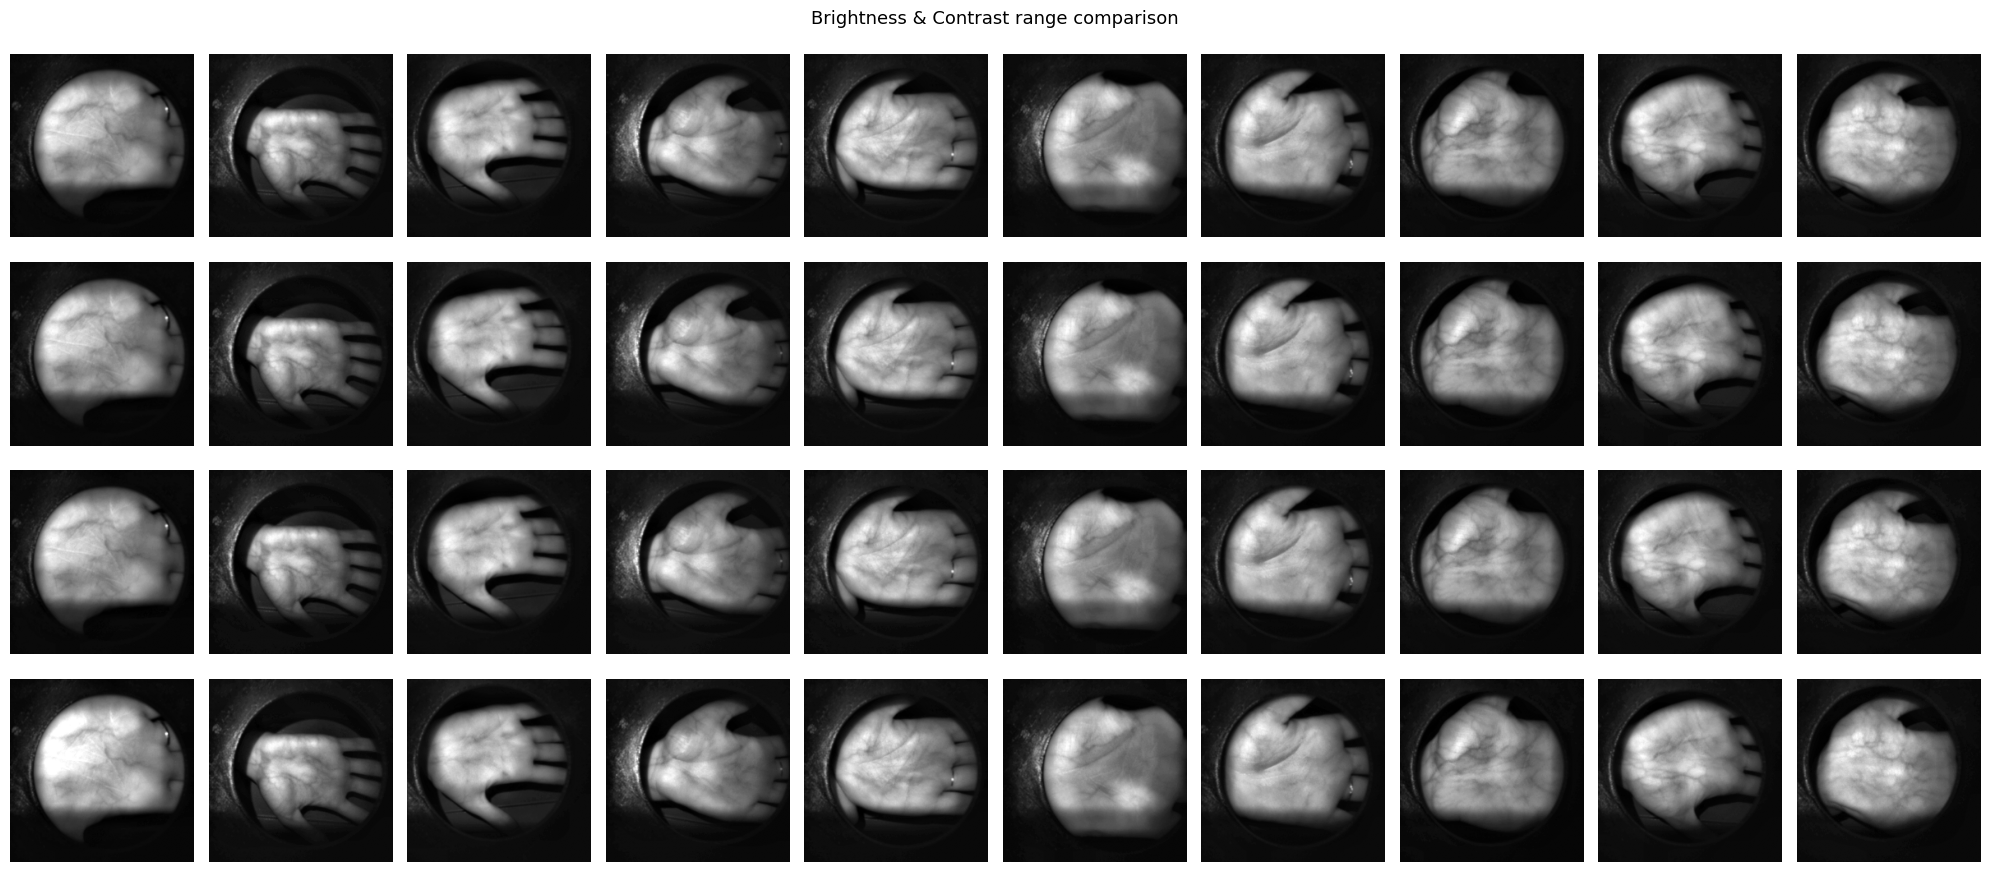

In [5]:
jitter_ranges = [0.1, 0.2, 0.4]

fig, axes = plt.subplots(len(jitter_ranges) + 1, 10, figsize=(20, 9))

for i, path in enumerate(sample_paths):
    axes[0, i].imshow(Image.open(path), cmap='gray')
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=9)

for r, v in enumerate(jitter_ranges):
    jitter = T.ColorJitter(brightness=v, contrast=v)
    for i, path in enumerate(sample_paths):
        axes[r + 1, i].imshow(jitter(Image.open(path)), cmap='gray')
        axes[r + 1, i].axis('off')
    axes[r + 1, 0].set_ylabel(f'b={v}, c={v}', fontsize=9)

plt.suptitle('Brightness & Contrast range comparison', fontsize=13)
plt.tight_layout()
plt.show()



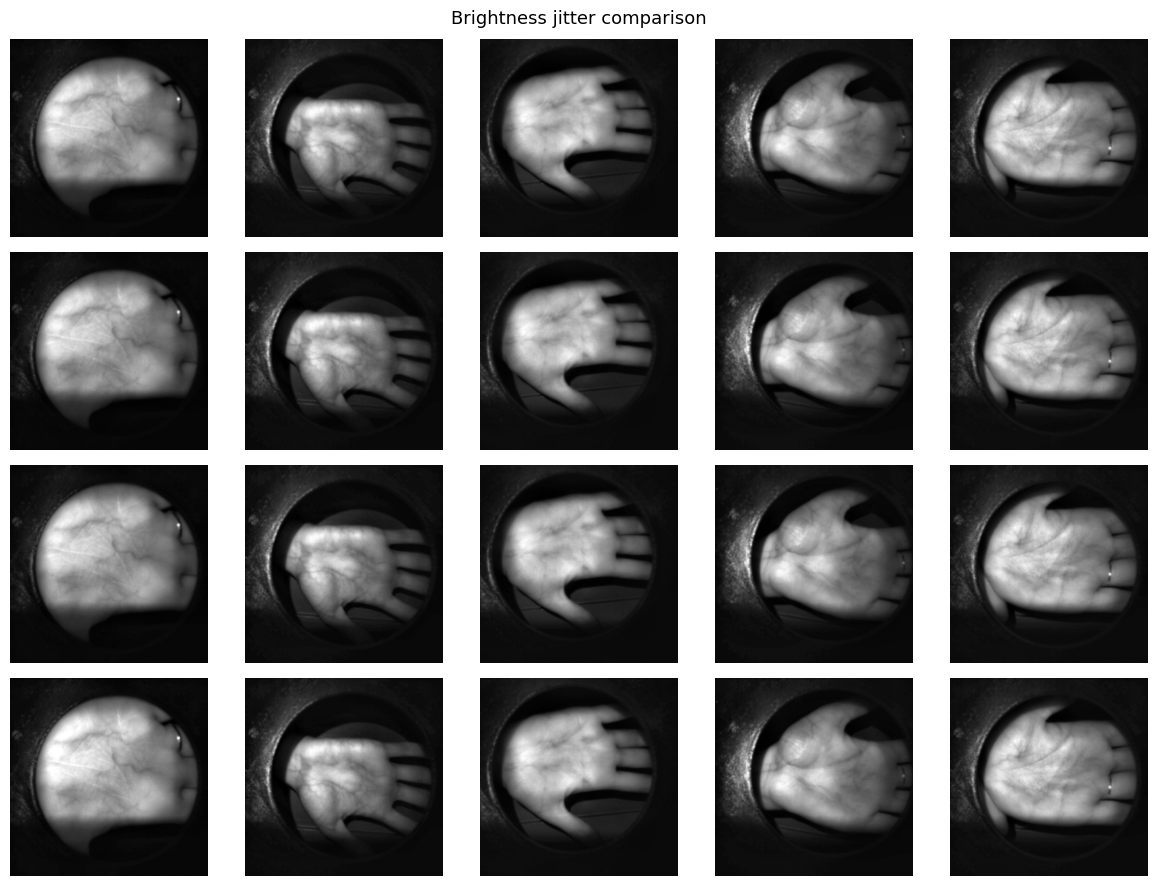

In [6]:
jitter_values = [0.1, 0.2, 0.3]

fig, axes = plt.subplots(len(jitter_values) + 1, 5, figsize=(12, 9))

for i, path in enumerate(sample_paths[:5]):
    axes[0, i].imshow(Image.open(path), cmap='gray')
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=9)

for r, v in enumerate(jitter_values):
    jitter = T.ColorJitter(brightness=v)
    for i, path in enumerate(sample_paths[:5]):
        axes[r + 1, i].imshow(jitter(Image.open(path)), cmap='gray')
        axes[r + 1, i].axis('off')
    axes[r + 1, 0].set_ylabel(f'brightness={v}', fontsize=9)

plt.suptitle('Brightness jitter comparison', fontsize=13)
plt.tight_layout()
plt.show()
